In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = pd.read_csv("C:/Users/sahil/sonalll/bitcoin data.csv")
print(data.head())

print(data.info())
print(data.isnull().sum())

         Date        Open        High         Low       Close   Adj Close  \
0  2014-09-17  465.864014  468.174011  452.421997  457.334015  457.334015   
1  2014-09-18  456.859985  456.859985  413.104004  424.440002  424.440002   
2  2014-09-19  424.102997  427.834991  384.532013  394.795990  394.795990   
3  2014-09-20  394.673004  423.295990  389.882996  408.903992  408.903992   
4  2014-09-21  408.084991  412.425995  393.181000  398.821014  398.821014   

     Volume  
0  21056800  
1  34483200  
2  37919700  
3  36863600  
4  26580100  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-nu

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')
data = data.dropna()
print(data.describe())

                                Date          Open          High  \
count                           2713   2713.000000   2713.000000   
mean   2018-06-04 00:00:00.000000256  11311.041069  11614.292482   
min              2014-09-17 00:00:00    176.897003    211.731003   
25%              2016-07-26 00:00:00    606.396973    609.260986   
50%              2018-06-04 00:00:00   6301.569824   6434.617676   
75%              2020-04-12 00:00:00  10452.399414  10762.644531   
max              2022-02-19 00:00:00  67549.734375  68789.625000   
std                              NaN  16106.428891  16537.390649   

                Low         Close     Adj Close        Volume  
count   2713.000000   2713.000000   2713.000000  2.713000e+03  
mean   10975.555057  11323.914637  11323.914637  1.470462e+10  
min      171.509995    178.102997    178.102997  5.914570e+06  
25%      604.109985    606.718994    606.718994  7.991080e+07  
50%     6214.220215   6317.609863   6317.609863  5.098183e+09  
75%

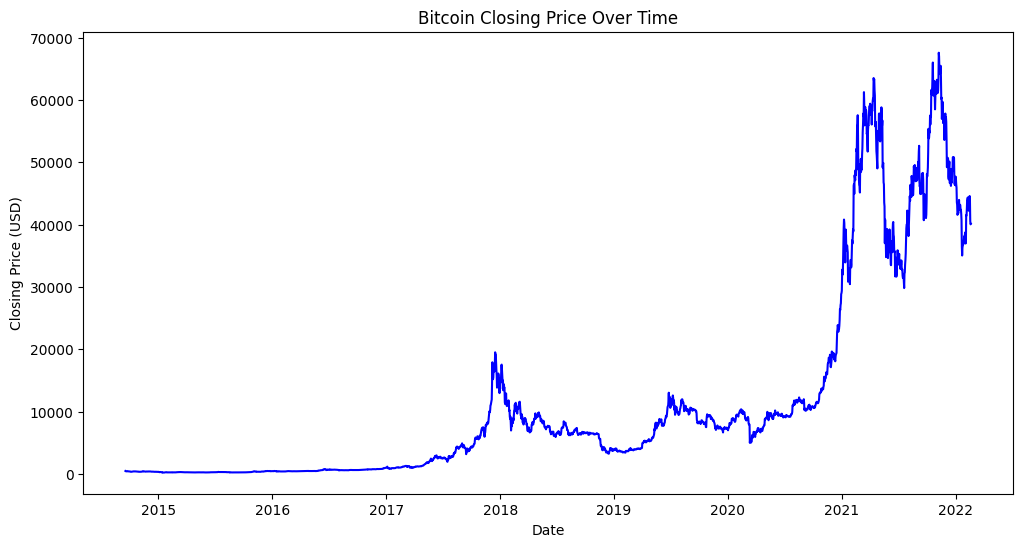

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'], color='blue')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.show()


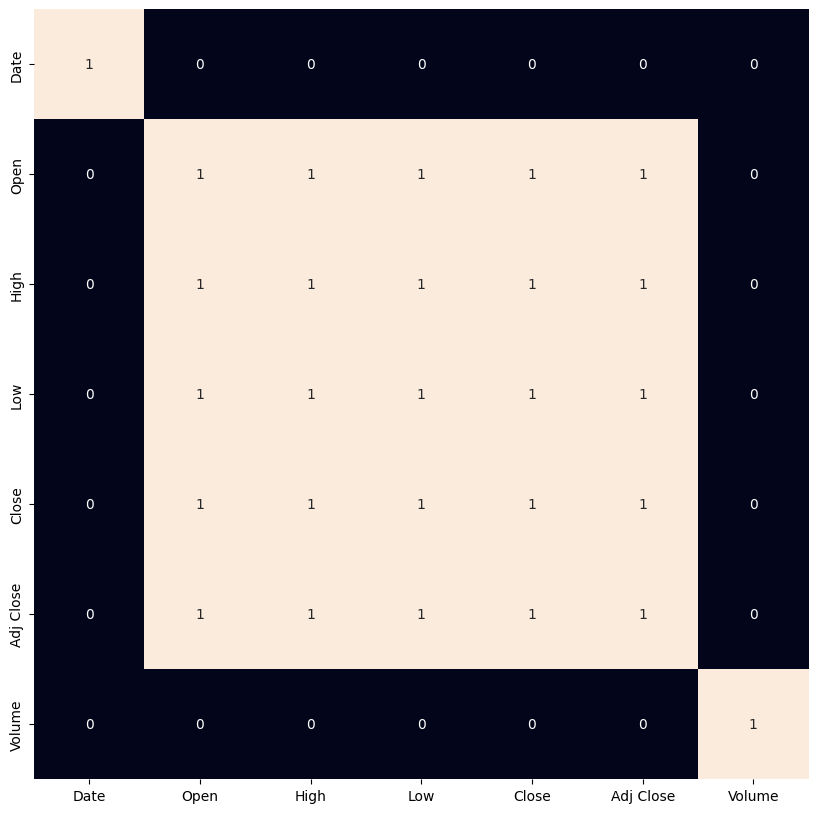

In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr() > 0.9, annot=True, cbar=False)
plt.show()

C:\Users\sahil\AppData\Local\Temp\ipykernel_23996\3716588023.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[col])
C:\Users\sahil\AppData\Local\Temp\ipykernel_23996\3716588023.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[col])
C:\Users\sahil\AppData\Local\Temp\ipykernel_2399

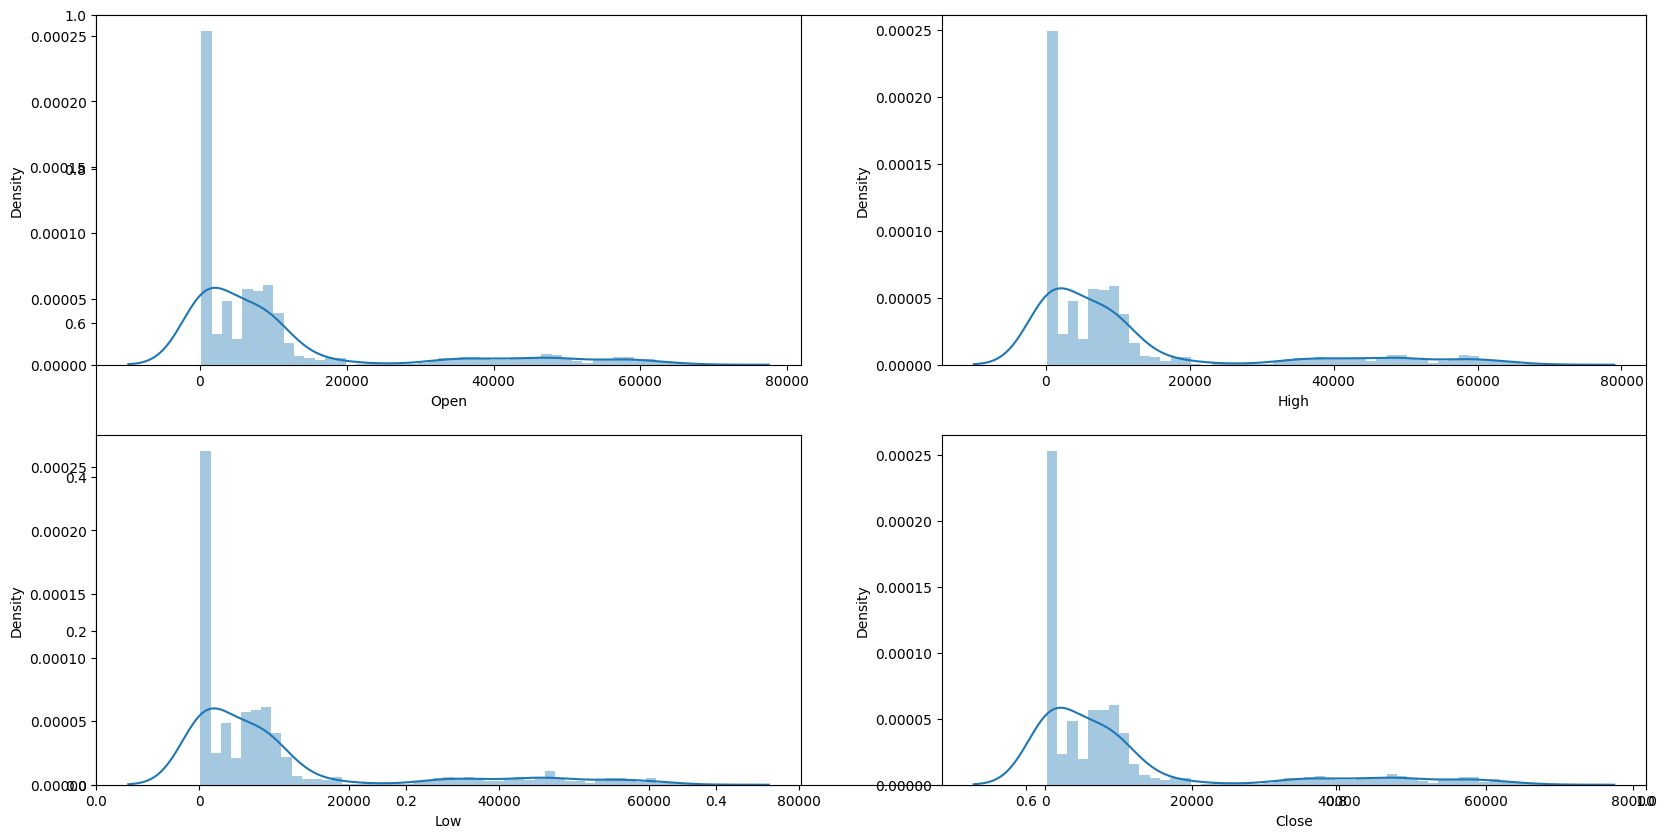

In [ ]:
features = ['Open', 'High', 'Low', 'Close']
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,2,i+1)
  sns.distplot(data[col])
plt.show()

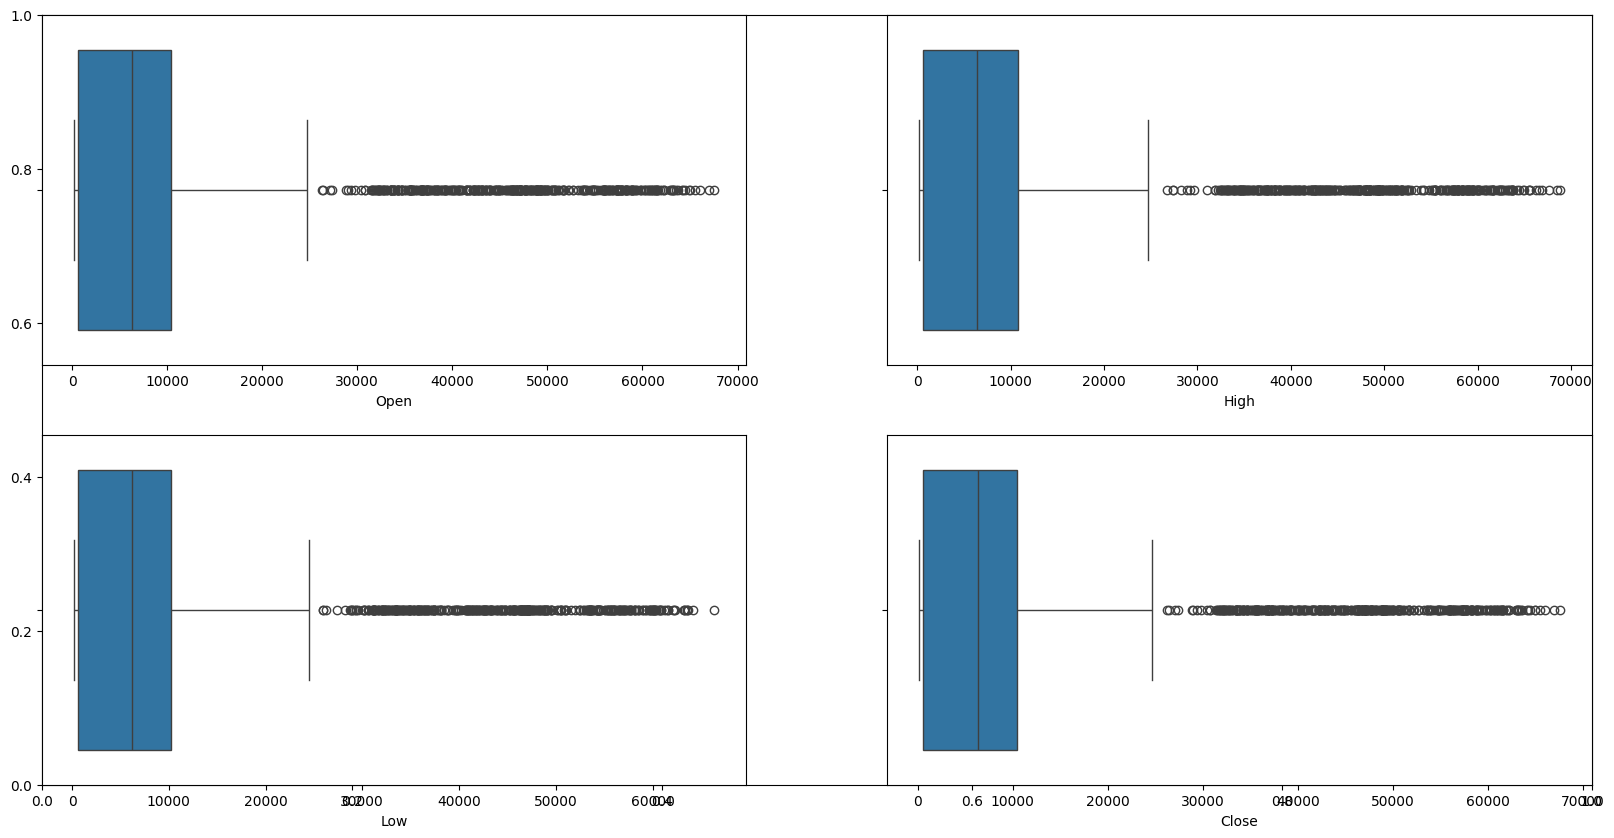

In [ ]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,2,i+1)
  sns.boxplot(data[col], orient='h')
plt.show()

In [ ]:
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Close']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())

            Actual     Predicted
506     386.549011    389.787435
1535   4017.268555   4087.831358
1905   7448.307617   7649.232980
930    1133.250000   1136.591676
2676  43099.699219  42650.222847


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Absolute Error: 141.3063414214839
Mean Squared Error: 107039.07808960916
R² Score: 0.9996103476618028


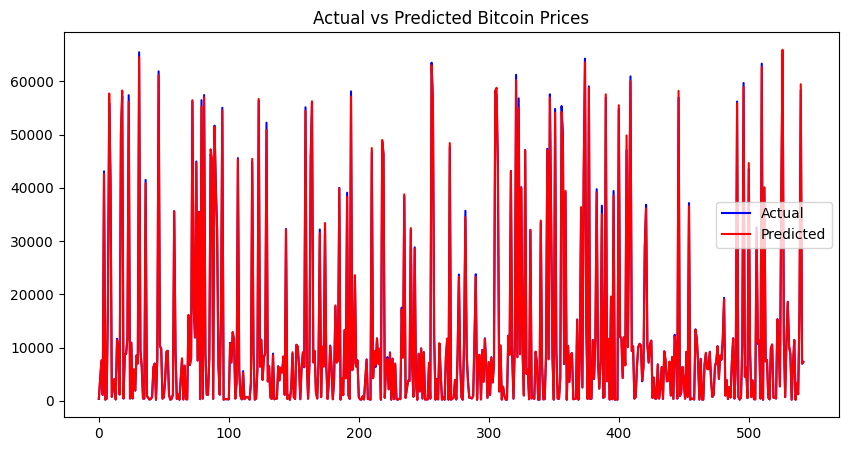

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title('Actual vs Predicted Bitcoin Prices')
plt.legend()
plt.show()